In [27]:
import keras_ocr
import matplotlib.pyplot as plt
import time
import os
import random

In [2]:
# setup pipeline with keras-ocr
# the model is pre-trained text extraction model loaded
# with pre-trained weights for the detector and recognizer
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5


2022-12-24 10:31:50.252323: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2022-12-24 10:31:50.252349: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (greystone-B560M-GAMING-HD): /proc/driver/nvidia/version does not exist
2022-12-24 10:31:50.252709: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


In [68]:
# read the images
urls = ['imgs/img3.jpg','imgs/img4.jpg','imgs/img5.jpg','imgs/img6.jpg']
images = [keras_ocr.tools.read(url) for url in urls]

In [69]:
print(len(images))
print(images[0].shape) # (h,w,color)

4
(1500, 1000, 3)


In [70]:
def exec_func(f):
    '''
    execute the function and messuring time
    Args:
        f: function
    Return:
        printing out time
    '''
    start = time.time()
    f() # execute the function
    duration = time.time() -start
    print(f'{f.__name__.ljust(10)}:{duration:.2f} (s)',flush=True)
    
def one_by_one():
    return [pipeline.recognize([image]) for image in images]

def batch():
    return pipeline.recognize(images)

In [71]:
for i in range(3):
    exec_func(one_by_one)
    #exec_func(batch) dead kernel

2/2 [==============================] - 1s 276ms/step
one_by_one:30.57 (s)
2/2 [==============================] - 1s 276ms/step
one_by_one:32.91 (s)
2/2 [==============================] - 1s 328ms/step
one_by_one:34.99 (s)


In [77]:
# recognize one image
out = pipeline.recognize([images[0]])

7/7 [==============================] - 6s 793ms/step


In [73]:
# output of pipeline
print(type(out))
print(len(out))
# element in output
print(type(out[0]))
print(len(out[0]))
# element in output
print(type(out[0][0]))
print(len(out[0][0]))

<class 'list'>
1
<class 'list'>
208
<class 'tuple'>
2


In [78]:
print(out[0][0])

('nutrition', array([[625.6362  ,  11.110786],
       [905.6068  ,  13.588401],
       [905.16766 ,  63.220676],
       [625.1971  ,  60.743065]], dtype=float32))


In [79]:
# print out predicted text
for text,box in out[0]:
    print(text)
    print(box)

nutrition
[[625.6362    11.110786]
 [905.6068    13.588401]
 [905.16766   63.220676]
 [625.1971    60.743065]]
information
[[275.39062  68.84766]
 [662.1094   68.84766]
 [662.1094  118.65234]
 [275.39062 118.65234]]
laverage
[[672.3633   77.63672]
 [908.2031   77.63672]
 [908.2031  120.11719]
 [672.3633  120.11719]]
servings
[[ 85.78229 142.92572]
 [198.23871 151.413  ]
 [195.2437  191.09702]
 [ 82.78727 182.60976]]
package
[[240.23438 147.94922]
 [350.09766 147.94922]
 [350.09766 187.5    ]
 [240.23438 187.5    ]]
7
[[366.21094 149.41406]
 [382.32422 149.41406]
 [382.32422 175.78125]
 [366.21094 175.78125]]
per
[[196.28906 152.34375]
 [241.69922 152.34375]
 [241.69922 188.96484]
 [196.28906 188.96484]]
serving
[[ 85.89222 191.27385]
 [185.23973 198.77179]
 [182.2447  238.45583]
 [ 82.8972  230.95789]]
metric
[[336.91406 194.82422]
 [418.9453  194.82422]
 [418.9453  231.44531]
 [336.91406 231.44531]]
size
[[183.10547 196.28906]
 [235.83984 196.28906]
 [235.83984 231.44531]
 [183.10547 

<AxesSubplot: >

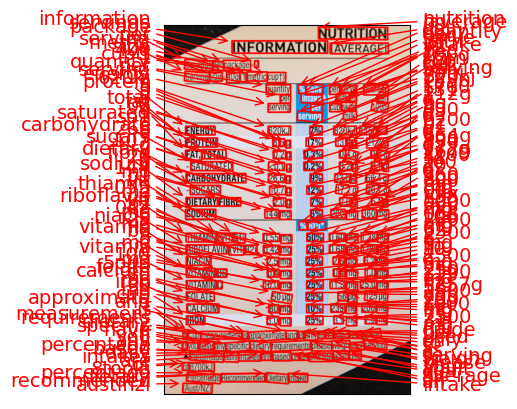

<Figure size 1000x1000 with 0 Axes>

In [80]:
# create just a figure and only one subplot
fig,ax = plt.subplots()
plt.figure(figsize=(10,10))
# draw prediction
keras_ocr.tools.drawAnnotations(image=images[0],predictions=out[0],ax=ax)

In [81]:
d = 'imgs'
images = os.listdir(d)
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5
Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


1/1 [==============================] - 0s 138ms/step
comsumming time: 4.29 (s)


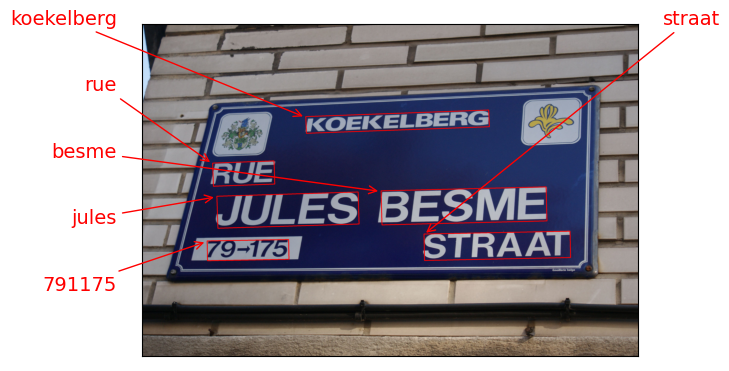

In [85]:
start = time.time()

# predict one image
img = random.choice(images)
img = d+"/"+img
imgs = [keras_ocr.tools.read(img)] # list input but one element
preds = pipeline.recognize(imgs)
# draw prediction
fig,ax = plt.subplots()
# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

duration = time.time() - start

print(f'comsumming time: {duration:.2f} (s)',flush=True)

In [87]:
# test on devices
d = 'devices'
images = os.listdir(d)
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5
Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


1/1 [==============================] - 1s 567ms/step
comsumming time: 5.24 (s)


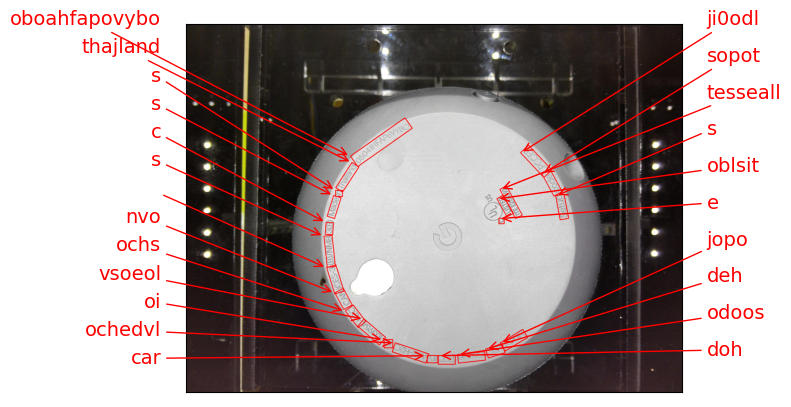

In [89]:
start = time.time()

# predict one image
img = random.choice(images)
img = d+"/"+img
imgs = [keras_ocr.tools.read(img)] # list input but one element
preds = pipeline.recognize(imgs)
# draw prediction
fig,ax = plt.subplots()
# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

duration = time.time() - start
plt.savefig('pred.png')
print(f'comsumming time: {duration:.2f} (s)',flush=True)

# References

[docs](https://keras-ocr.readthedocs.io/en/latest/api.html)

[educba](https://www.educba.com/keras-ocr/)

[Extract Text from Images Quickly Using Keras-OCR Pipeline
](https://www.analyticsvidhya.com/blog/2022/09/extract-text-from-images-quickly-using-keras-ocr-pipeline/)

[TensorFlow warnings about unnecessary retracing](https://github.com/faustomorales/keras-ocr/issues/63)